<a href="https://colab.research.google.com/github/Vickytoreeya/Vic-Token/blob/main/Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#When training models, it can take weeks or days for the training to be complete. GPU is better cos of the space and colab is one of the best places to use as you are running it on cloud.


0. Setup and import Libraries
Run this cell to import

In [ ]:
# import baseline libraries for handling data and drawing plots
import numpy as np #for numbers
import pandas as pd #for data manupilation
import matplotlib.pyplot as plt #for visualization
import seaborn as sns #for fancy visualization
import time

#import ML and DL Modules
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# To ensure the plot display inline
# %matplotlib inline

print("Tensorflow version", tf.__version__)


Tensorflow version 2.20.0


Relationship btw AI, ML, DL
AI is the entire concept.
ML - learns from data. It suffers some limitations like complex data, image, handwriting, speech
DL - handles the complexity of ML

In [ ]:
#1: Creating basic Tensors in Tensorflow

# Creating a scalar (0D tensor)
scalar_tensor = tf.constant(19)
print('scalar (0D Tensor):', scalar_tensor)

scalar (0D Tensor): tf.Tensor(19, shape=(), dtype=int32)


In [ ]:
# creating a vector (1D tensor)
vector_tensor = tf.constant([25, 30, 60, 20, 67])
print(f'vector: {vector_tensor}')

vector: [25 30 60 20 67]


In [ ]:
# creating a matrix (2D tensor)
matrix_tensor = tf.constant([[1,2],[3,4]])
print(f'matrix: {matrix_tensor}')

matrix: [[1 2]
 [3 4]]


In [ ]:
# converting between Numpy and Tensorflow Tensors
# creating a simple Numpy array
np_array = np.array([10,20,30])
print(np_array)

# convert Numpy array to TensorFlow Tensor
tf_tensor = tf.convert_to_tensor(np_array)
print(tf_tensor)

#convert tensorflow Tensor back to Numpy array
back_to_numpy = tf_tensor.numpy()
print(back_to_numpy)

[10 20 30]
tf.Tensor([10 20 30], shape=(3,), dtype=int64)
[10 20 30]


In [ ]:
#write a code to perform the following
#1 Create two 1D Tensor variable with at least 3 elements each. On these variables
#2 compute basic addition
#3 compute basic subtraction
#4 compute basic multiplication


In [ ]:
tensor_1 = tf.constant([25, 30, 60, 20, 67])
tensor_2 = tf.constant([52, 90, 70, 10, 5])
print(tensor_1)
print(tensor_2)
print(f'vector: {tensor_1}')
print(f'vector: {tensor_2}')

#addition
addition = tensor_1 + tensor_2
print(f'vector: {addition}')

#subtraction
Sub = tensor_1 - tensor_2
print(f'vector: {Sub}')

#Multiply
Multiply = tensor_1 * tensor_2
print(f'vector: {Multiply}')

tf.Tensor([25 30 60 20 67], shape=(5,), dtype=int32)
tf.Tensor([52 90 70 10  5], shape=(5,), dtype=int32)
vector: [25 30 60 20 67]
vector: [52 90 70 10  5]
vector: [ 77 120 130  30  72]
vector: [-27 -60 -10  10  62]
vector: [1300 2700 4200  200  335]


In [ ]:
#given that matrix a is 1,2,3,4 and b is 5,6,7,8
#write a code to multiply both matrices

a = tf.constant([[1,2],[3,4]])

b = tf.constant([[5,6],[7,8]])

#multiply
multiply = tf.matmul(a,b)
print(f'matrix: {multiply}')

matrix: [[19 22]
 [43 50]]


In [ ]:
# Create an instance of the dataset
california_housing = fetch_california_housing()
X_reg = pd.DataFrame(california_housing.data, columns=california_housing.feature_names)
y_reg = california_housing.target

X_reg.head()
#print(y_reg[:5])

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Split the dataset (80/20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
#random_state=42 for reproducity i.e the ability to produce the same results

In [ ]:
# We fit the scaler ONLY on the training data, and then use that same fitted scaler to transform both the tr
scaler = StandardScaler() #create an instance of the class
X_train_scaled = scaler.fit_transform(X_train_reg)
X_test_scaled = scaler.transform(X_test_reg)
print(X_train_scaled[0])
print(X_test_scaled[0])

[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
 -1.3728112   1.27258656]
[-1.15508475 -0.28632369 -0.52068576 -0.17174603 -0.03030109  0.06740798
  0.1951      0.28534728]


In [ ]:
# Model accepts inputs inform of a tuple. And as such it ends with a ,

In [ ]:
#Build the Brain of the AI
model_reg = Sequential()
model_reg.add(Dense(64, activation='relu', input_shape=(X_train_reg.shape[1],)))
model_reg.add(Dense(1))

model_reg.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#loss function tells us how bad our error is
model_reg.compile(optimizer='adam', loss='mean_squared_error')
print('model compiled successfully')

model compiled successfully


In [ ]:
history = model_reg.fit(
    X_train_scaled,
    y_train_reg,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 1.5864 - val_loss: 0.7644
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6368 - val_loss: 0.5838
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5048 - val_loss: 0.4930
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4424 - val_loss: 0.4561
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4158 - val_loss: 0.4358
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4002 - val_loss: 0.4214
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3879 - val_loss: 0.4179
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3813 - val_loss: 0.4331
Epoch 9/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3915 - val_loss: 0.4142
Epoch 10/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3932 - val_loss: 0.4043


In [ ]:
#fit is to train a model
#predict is to evaluate the performance

In [ ]:
preds = model_reg.predict(X_test_scaled)
mse = mean_squared_error(y_test_reg, preds)
print(mse)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
0.3872161940943735


Text(0, 0.5, 'Predicted House Price')

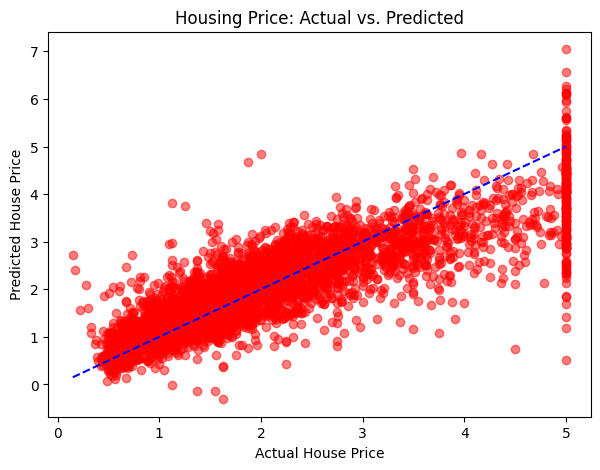

In [ ]:
# Visualization
plt.figure(figsize=(7,5))
plt.scatter(y_test_reg,preds, alpha=0.5, color='red')
plt.plot([y_test_reg.min(), y_test_reg.max()],[y_test_reg.min(), y_test_reg.max()],'b--')
plt.title('Housing Price: Actual vs. Predicted')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')


In [ ]:
# Import baseline and Deep Learning libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score

print("TensorFlow version loaded successfully:", tf.__version__)

TensorFlow version loaded successfully: 2.20.0


## Problem 1: Advertising Sales Prediction (Regression 1)

### Business Scenario:
You are an advertising executive. You want to predict product **Sales** (in thousands of units) based on the budget spent on **TV**, **Radio**, and **Newspaper** advertisement channels (in thousands of dollars).

### Dataset:
Run the code cell below to create the dataset as a Pandas DataFrame.

In [ ]:
# Create the advertising dataset
np.random.seed(42)
n_samples = 30
tv = np.random.uniform(10, 300, n_samples)
radio = np.random.uniform(5, 50, n_samples)
newspaper = np.random.uniform(2, 80, n_samples)

# true relation: sales = 10 + 0.05 * TV + 0.18 * Radio + 0.01 * Newspaper + Noise
sales = 10 + 0.05 * tv + 0.18 * radio + 0.01 * newspaper + np.random.normal(0, 2, n_samples)

df_adv = pd.DataFrame({'TV': tv, 'Radio': radio, 'Newspaper': newspaper, 'Sales': sales})
print("Dataset shape:", df_adv.shape)
display(df_adv.head())

Dataset shape: (30, 4)


,TV,Radio,Newspaper,Sales
0,118.616634,32.339518,32.316829,22.798385
1,285.707149,12.673586,23.165224,25.508016
2,222.278243,7.927322,66.641526,23.930037
3,183.610960,47.699849,29.826759,31.140862
4,55.245406,48.453441,23.912892,21.651367


### Task 1.1: Split the Data
Split the dataset into features (`X`) and target (`y`). Then split them into training sets (80%) and testing sets (20%) using `train_test_split` with `random_state=42`.

In [ ]:
# Task 1.1
# Split the dataset (80/20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
#random_state=42 for reproducity i.e the ability to produce the same results
print(X_train_reg)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
14196  3.2596      33.0  5.017657   1.006421      2300.0  3.691814     32.71   
8267   3.8125      49.0  4.473545   1.041005      1314.0  1.738095     33.77   
17445  4.1563       4.0  5.645833   0.985119       915.0  2.723214     34.66   
14265  1.9425      36.0  4.002817   1.033803      1418.0  3.994366     32.69   
2271   3.5542      43.0  6.268421   1.134211       874.0  2.300000     36.78   
...       ...       ...       ...        ...         ...       ...       ...   
11284  6.3700      35.0  6.129032   0.926267       658.0  3.032258     33.78   
11964  3.0500      33.0  6.868597   1.269488      1753.0  3.904232     34.02   
5390   2.9344      36.0  3.986717   1.079696      1756.0  3.332068     34.03   
860    5.7192      15.0  6.395349   1.067979      1777.0  3.178891     37.58   
15795  2.5755      52.0  3.402576   1.058776      2619.0  2.108696     37.77   

       Longitude  
14196    -117.03  
8

In [ ]:
# Task 1.2
# Instantiate a `StandardScaler`, fit it on the training features, and transform both training and test features.
scaled = StandardScaler()
X_train_scaled = scaled.fit_transform(X_train_reg)
X_test_scaled = scaled.transform(X_test_reg)
print(X_train_scaled[0])
print(X_test_scaled[0])

[-0.326196    0.34849025 -0.17491646 -0.20836543  0.76827628  0.05137609
 -1.3728112   1.27258656]
[-1.15508475 -0.28632369 -0.52068576 -0.17174603 -0.03030109  0.06740798
  0.1951      0.28534728]


In [ ]:
# Task 1.3
# Build a Sequential Neural Network containing:
#1. A Dense input layer with 32 neurons, ReLU activation function, and the correct `input_shape`.
#2. A Dense hidden layer with 16 neurons and ReLU activation.
#3. A Dense output layer with 1 neuron (no activation function since this is regression). Regression predicts only 1

#Print the model summary.

model_task = Sequential()
model_task.add(Dense(32, activation='relu', input_shape=(X_train_reg.shape[1],)))
model_task.add(Dense(16, activation='relu'))
model_task.add(Dense(1))

model_task.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
### Task 1.4: Compile and Train the Model
#Compile the model using the `adam` optimizer and `mean_squared_error` loss.
#Then train it for **50 epochs** with a `batch_size` of `4` and `validation_split=0.1`.

#loss function tells us how bad our error is
model_task.compile(optimizer='adam', loss='mean_squared_error')
print('model compiled successfully')

model compiled successfully
